# ROM1 Base-Excitation Bifurcation Study


In [2]:
import sys
from pathlib import Path
import importlib
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

try:
    from joblib import Parallel, delayed
    HAS_JOBLIB = True
except ImportError:
    HAS_JOBLIB = False

# Ensure workspace root containing Modeling/ is first on sys.path.
cwd = Path.cwd().resolve()
project_root = next((p for p in [cwd, *cwd.parents] if (p / 'Modeling').is_dir()), None)
if project_root is None:
    raise RuntimeError('Could not find project root containing Modeling/.')
sys.path.insert(0, str(project_root))

from Modeling.models.beam_properties import PiezoBeamParams
import Modeling.models.ROM1 as rom1_module
importlib.reload(rom1_module)
ROM = rom1_module.ROM


Project root: E:\GaTech Dropbox\Seyednima Etemadi\Projects\Metamaterial beam
Joblib available: True
First natural frequency [Hz]: 5.69543112994812
Electromechanical coupling: 0.00036615349431026213
Cp_scalar [nF]: 10.894621964621964


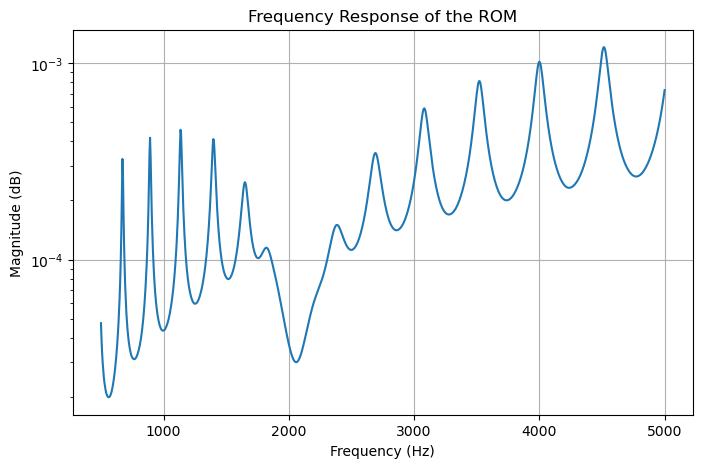

In [3]:
# model parameters and ROM setup
print(f'Project root: {project_root}')
print(f'Joblib available: {HAS_JOBLIB}')
params_rom = PiezoBeamParams(hp=0.252e-3, hs=0.51e-3)


N_modes = 20
rom = ROM(params=params_rom, N=N_modes, modal_damping_ratios=np.array([0.0065] * N_modes))

print('First natural frequency [Hz]:', rom.omega[0] / (2 * np.pi))
print('Electromechanical coupling:', (rom.p.theta_mech * rom.Gamma)[0, 0])
print('Cp_scalar [nF]:', rom.p.Cp_scalar * 1e9)

import pandas as pd
from scipy.signal import chirp
amp = 50
f0 = 500
f = 5000
K_p = 0.015
R_c = 1000
K_p = 0.015
K_i = 1820
K_c = 3e10

rtol = 1e-7
atol = 1e-9

ode_sys = rom.build_ode_system(
    j_exc=30,
    R_c=R_c,
    K_p=K_p,
    K_i=K_i,
    K_c=K_c,
)
freq_resp = rom.frequency_response_fe3(ode_sys, w= np.linspace(f0 , f, 1000)*2*np.pi)
x_eval  = np.linspace(0, rom.p.L_b, 100)
# print('Sweep points:', len(amps))
plt.figure(figsize=(8, 5))
plt.semilogy(freq_resp['freq_hz'], np.mean(np.abs(freq_resp['veloc']), axis=0), label='Frequency Response')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude (dB)')
plt.title('Frequency Response of the ROM')
plt.grid()
# plt.legend()
plt.show()

# %matplotlib widget

In [5]:
# # Single simulation 
# f0= 3000
# f = 3100
# n_periods_total = 5000
# n_periods_keep = 4000
# points_per_period = 100
# T = 1 / f
# dt = T / points_per_period
# t_end  = n_periods_total * T
# t_eval = np.arange(0, t_end, dt)
# def v_exc(t):
#     t1 = t_end / 5
#     t = np.asarray(t)
#     out = amp * np.cos(2 * np.pi * f * t)
#     out = np.where(t < t1, amp * chirp(t, f0=f0, f1=f, t1=t1, method="linear"), out)
#     return out

# # def v_exc(t):
# #     return amp * chirp(t, f0=f0, f1=f, t1=t_end, method="linear")

# r = rom.run_time_sim(
#     v_exc=v_exc,
#     j_exc=30,
#     R_c=R_c,
#     K_p=K_p,
#     K_i=K_i,
#     K_c=K_c,
#     t_end=t_end,
#     t_eval=t_eval,
#     x_eval=x_eval,
#     rtol=rtol,
#     atol=atol,
#     )

In [4]:
# Utilities: Stroboscopic sampling for Poincaré map,  lazy loading of .npz files
def make_fe3_rhs(ode_sys):
    """Convert FE3 second-order form to first-order for solve_ivp."""
    M = ode_sys.M
    n = M.shape[0]
    M_diag = np.diag(M)
    is_diagonal = np.allclose(M, np.diag(M_diag), rtol=1e-12, atol=1e-15)

    if is_diagonal:
        if np.any(np.isclose(M_diag, 0.0)):
            raise ValueError("Mass matrix is diagonal but has near-zero diagonal entries.")
        M_inv_diag = 1.0 / M_diag
        print("RHS solve mode: diagonal mass matrix (elementwise divide)")
    else:
        print("RHS solve mode: dense mass matrix (np.linalg.solve)")

    def rhs(t, y):
        x = y[:n]
        x_dot = y[n:]
        residual = ode_sys.f_ext(t) - ode_sys.C @ x_dot - ode_sys.f_int(x)

        if is_diagonal:
            x_ddot = M_inv_diag * residual
        else:
            x_ddot = np.linalg.solve(M, residual)

        return np.concatenate([x_dot, x_ddot])

    return rhs


class LazyNPZ:
    """Load a single array from a compressed .npz archive only when requested."""

    def __init__(self, path, **metadata):
        self.path = str(path)
        self._metadata = dict(metadata)
        self._cache = {}
        with np.load(self.path, allow_pickle=True) as data:
            self._keys = tuple(data.files)

    @property
    def keys(self):
        return self._keys

    def __contains__(self, key):
        return key in self._metadata or key in self._keys

    def __getitem__(self, key):
        if key in self._metadata:
            return self._metadata[key]
        if key not in self._keys:
            raise KeyError(key)
        if key not in self._cache:
            with np.load(self.path, allow_pickle=True) as data:
                self._cache[key] = data[key]
        return self._cache[key]

    def get(self, key, default=None):
        return self[key] if key in self else default

    def load(self, *keys):
        if len(keys) == 1:
            return self[keys[0]]
        with np.load(self.path, allow_pickle=True) as data:
            return {key: data[key] for key in keys}


def stroboscopic_sample(t, response, points_per_period, n_periods_keep=None):
    """Return the steady-state stroboscopic samples for a periodic response."""
    if n_periods_keep is None:
        n_periods_keep = len(t) // points_per_period
    response = np.asarray(response)
    strobe_indices = np.arange(0, len(t), points_per_period)
    t_strobe = t[strobe_indices]

    if response.ndim == 1:
        response_strobe = response[strobe_indices]
    else:
        response_strobe = response[..., strobe_indices]

    # Discard transient for the Poincaré map.
    return {
        "t_strobe": t_strobe[-n_periods_keep:],
        "response_poincare": response_strobe[..., -n_periods_keep:],
    }



def stroboscopic_sample_x_and_xdot(t, eta, eta_dot, z, v, points_per_period, n_periods_keep):
    """Return separate stroboscopic samples for displacement and velocity."""
    eta_sample = stroboscopic_sample(t, eta, points_per_period, n_periods_keep)
    eta_dot_sample = stroboscopic_sample(t, eta_dot, points_per_period, n_periods_keep)
    z_sample = stroboscopic_sample(t, z, points_per_period, n_periods_keep)
    v_sample = stroboscopic_sample(t, v, points_per_period, n_periods_keep)
    return {
        "t_strobe": eta_sample["t_strobe"],
        "eta_poincare": eta_sample["response_poincare"],
        "eta_dot_poincare": eta_dot_sample["response_poincare"],
        "z_poincare": z_sample["response_poincare"],
        "v_poincare": v_sample["response_poincare"],
    }


# Amplitude sweep

In [ ]:

amps = np.linspace(0.01, 0.4, 40)*125
import os
import uuid
from pathlib import Path

results_dir = Path("results_amp")
results_dir.mkdir(exist_ok=True)

def single_simulation(amp):
    f = 2977.94589
    f0 = 500
    n_periods_total = 10000
    n_periods_keep = 4000
    points_per_period = 100
    T = 1 / f
    dt = T / points_per_period
    t_end = n_periods_total * T
    t_eval = np.arange(0, t_end, dt)

    def v_exc(t):
        return amp * chirp(t, f0=f0, f1=f, t1=t_end, method="linear")
    
    def v_exc(t):
        t1 = t_end / 20
        t = np.asarray(t)
        out = 50 * np.cos(2 * np.pi * f * t)
        out = np.where(t < t1, 50 * chirp(t, f0=f0, f1=f, t1=t1, method="linear"), out)
        return out
    
    out = rom.run_time_sim(
        v_exc=v_exc,
        j_exc=30,
        R_c=R_c,
        K_p=K_p,
        K_i=K_i,
        K_c=K_c,
        t_end=t_end,
        t_eval=t_eval,
        x_eval=x_eval,
        rtol=rtol,
        atol=atol,
    )

    eta = out["eta"]
    eta_dot = out["eta_dot"]
    z = out["z"]
    v = out["v"]
    t = out["t"]

    arrays_to_save = {
        "t": t,
        "veloc": out["veloc"],
        "eta": eta,
        "eta_dot": eta_dot,
        "z": z,
        "v": v,
        "freq": out["freq"],
        "FRF": out["FRF"],
        "Y": out["Y"],
    }

    fname = results_dir / f"res_amp_{int(round(100*amp))}_{uuid.uuid4().hex}.npz"
    np.savez_compressed(fname, **arrays_to_save)

    return {"amp": float(amp), "file": str(fname)}

# Run workers (they now return small metadata + filename)
results_meta = Parallel(n_jobs=min(50, len(amps)), verbose=12)(
    delayed(single_simulation)(a) for a in amps
)


In [6]:


def make_lazy_results(results_meta=None, results_dir="results_amp"):
    if results_meta is None:
        return [LazyNPZ(p, amp=float(p.stem.split("_")[2]) / 100.0) for p in sorted(Path(results_dir).glob("res_amp_*.npz"))]
    return [LazyNPZ(m["file"], amp=float(m["amp"])) for m in results_meta]

results_amp = make_lazy_results(globals().get("results_meta"))
print(f"Prepared {len(results_amp)} lazy result handle(s). Access only the arrays you need, e.g. r['freq'] or r['FRF'].")

KeyboardInterrupt: 

In [5]:
results_amp = make_lazy_results(globals().get("results_meta"))
print(f"Prepared {len(results_amp)} lazy amplitude result handle(s).")
print("Example: results_amp[0]['freq'] or results_amp[0]['FRF'] loads just that array.")

NameError: name 'make_lazy_results' is not defined

In [ ]:
# FRF
plt.figure(figsize=(8, 5))
colors = plt.cm.viridis(np.linspace(0, 1, len(results_amp)))
for idx, r in enumerate(results_amp):
    plt.semilogy(r["freq"], np.abs(r["FRF"]),color=colors[idx],  alpha=0.95, label=f'A={r["amp"]:.2f}')
plt.xlabel('Frequency (Hz)')
plt.xlim(2900,  3200)
plt.ylim(1e-5, 1e-2)

In [ ]:
# Phase portraits for each piezo state pair
# =========================
# %matplotlib widget 
fig = plt.figure(figsize=(8.5, 5.8))
ax = fig.add_subplot(111, projection='3d')
ampidx = 3
r = results_amp[ampidx]

indices = [0, 5, 10, 15, 20 , 25]
colors = plt.cm.viridis(np.linspace(0, 1, len(indices) ))
n_periods_keep = 100000
t_inds_keep = n_periods_keep * 100
f0 = 2900
f = 3200
for i, (idx, z, v) in enumerate(zip(indices,r["z"][indices,:], r["v"][indices,:])):
    f_inst_theory = f0 + (f - f0) * r['t'] / r['t'][-1]  
    # ax.plot(np.ones_like(z)*idx, f_inst_theory, v, color=colors[i], lw=0.8, alpha=0.95)
    ax.plot(np.ones_like(z)*idx, r['t'], v, color=colors[i], lw=0.8, alpha=0.95)

ax.set_xlabel('Piezo index')
ax.set_xticks(indices)
ax.set_ylabel('time [s]')
ax.set_zlabel('v [V]')
ax.set_title(f'Excitation voltage= {amps[ampidx]:.0f}V')
ax.grid(False )
ax.legend(loc='best', fontsize=8, ncol=2)
fig.tight_layout()
plt.show()


In [ ]:
# single time series plot for one piezo state pair
ampidx = 3
fig, ax = plt.subplots(figsize=(8.5, 5.8))
r = results_amp[ampidx]
ax.plot(r["t"], r["v"][5, :], label='v(t) of piezo 0')
ax.set_xlabel('Time [s]')
ax.set_ylabel('Voltage [V]')
ax.set_title(f'Excitation voltage= {amps[ampidx]:.0f}V')
ax.grid(True)
f0 = 2900
f = 3200
f_inst_theory = f0 + (f - f0) * r["t"] / r["t"][-1]
ax_top = ax.twiny()
ax_top.set_xlim(ax.get_xlim())
t_ticks = np.linspace(r["t"][0], r["t"][-1], 6)
ax.set_xticks(t_ticks)
ax_top.set_xticks(t_ticks)
ax_top.set_xticklabels([f'{f0 + (f - f0) * t / r["t"][-1]:.0f}' for t in t_ticks])
ax_top.xaxis.set_ticks_position('bottom')
ax_top.xaxis.set_label_position('bottom')
ax_top.spines['bottom'].set_position(('outward', 36))
ax_top.spines['top'].set_visible(False)
ax_top.set_xlabel('Instantaneous Frequency [Hz]')
ax.legend()
fig.tight_layout()
plt.show()

# Freq sweep 


In [ ]:
import os
import uuid
from pathlib import Path
import pickle



freqs = np.linspace(2955, 2980, 500)
results_dir = Path("results_freq")
results_dir.mkdir(exist_ok=True)

def single_simulation(f):
    amp = 50
    f0 = 500
    n_periods_total = 10000
    n_periods_keep = 5000
    points_per_period = 100
    T = 1 / f
    dt = T / points_per_period
    t_end  = n_periods_total * T
    t_eval = np.arange(0, t_end, dt)
    def v_exc(t):
        t1 = t_end / 10 ->20
        t = np.asarray(t)
        out = 50 * np.cos(2 * np.pi * f * t)
        out = np.where(t < t1, 50 * chirp(t, f0=f0, f1=f, t1=t1, method="linear"), out)
        return out

    # def v_exc(t):
    #     return amp * chirp(t, f0=0, f1=f, t1=t_end, method="linear")

    out = rom.run_time_sim(
        v_exc=v_exc,
        j_exc=30,
        R_c=R_c,
        K_p=K_p,
        K_i=K_i,
        K_c=K_c,
        t_end=t_end,
        t_eval=t_eval,
        x_eval=x_eval,
        rtol=rtol,
        atol=atol,
    )

    # Mechanical modal coordinates are the first rom.N entries of x(t).
    eta = out["eta"]
    eta_dot = out["eta_dot"]
    z = out["z"]
    v = out["v"]

    t = out["t"]

    strobe = stroboscopic_sample_x_and_xdot(t, eta, eta_dot, z, v, points_per_period, n_periods_keep)

    arrays_to_save = {
        "t": t,
        'f': f,
        "veloc": out["veloc"],
        "eta": eta,
        "eta_dot": eta_dot,
        "z": z,
        "v": v,
        "freq": out["freq"],
        "FRF": out["FRF"],
        "Y": out["Y"],
        "t_strobe": strobe["t_strobe"],
        "eta_poincare": strobe["eta_poincare"],
        "eta_dot_poincare": strobe["eta_dot_poincare"],
        "z_poincare": strobe["z_poincare"],
        "v_poincare": strobe["v_poincare"],
    }

    fname = results_dir / f"res_freq_{int(round(f))}_{uuid.uuid4().hex}.npz"
    np.savez_compressed(fname, **arrays_to_save)

    return {"f": float(f), "file": str(fname)}

n_workers = min(len(freqs), max(1, os.cpu_count() or 1), 30)
results_meta_freq = Parallel(n_jobs=n_workers, verbose=12)(
    delayed(single_simulation)(f) for f in freqs
)

# Helper to load saved .npz
def load_result_file(path):
    with np.load(path, allow_pickle=True) as data:
        return {k: data[k] for k in data.files}

# Build full in-memory results list only when/if needed:
results_freq = []
for m in results_meta_freq:
    d = load_result_file(m["file"])
    d["f"] = m["f"]
    d["file"] = m["file"]
    results_freq.append(d)

with open(results_dir / "results_meta_freq.pkl", "wb") as f:
    pickle.dump(results_meta_freq, f)
print(f"Loaded {len(results_freq)} frequency results from {results_dir} using {n_workers} worker(s).")

In [8]:
# Lazy loading version:
import pickle
results_dir = Path("results_freq")
with open(results_dir / "results_meta.pkl", "rb") as f:
    results_meta = pickle.load(f)
def make_lazy_results(results_meta, results_dir):
    
    # return [LazyNPZ(m["file"], sweep_param=float(m["sweep_param"])) for m in results_meta]
    return [LazyNPZ(m["file"], sweep_param=float(m["f"])) for m in results_meta]

results = make_lazy_results(results_meta, results_dir)
print(f"Prepared {len(results_meta)} lazy result handle(s).")


Prepared 500 lazy result handle(s).


In [ ]:
# 3D Phase portraits frequency sweep
fig = plt.figure(figsize=(8.5, 5.8))
ax = fig.add_subplot(111, projection='3d')
fidx = -1
r = results_freq[fidx]
n_periods_total = 10000
n_periods_keep = 5000
points_per_period = 100
indices = [0, 5, 10, 15, 20 , 25]
colors = plt.cm.viridis(np.linspace(0, 1, len(indices) ))
# n_periods_keep = 2000
t_inds_keep = n_periods_keep * points_per_period
for i, (idx, z, v) in enumerate(zip(indices,r["z"][indices,-t_inds_keep:], r["v"][indices,-t_inds_keep:])):
    print(z.shape )
    ax.scatter(np.ones_like(z)*idx, z, v,s=1, color=colors[i], lw=1.2, alpha=0.95)

ax.set_xlabel('Piezo index')
ax.set_xticks(indices)
ax.set_zlabel('v [V]')
ax.set_ylabel('z [V.s]')
ax.set_title(f'Phase portrait at {freqs[fidx]:.0f} Hz')
ax.grid(True)
# ax.legend(loc='best', fontsize=8, ncol=2)
fig.tight_layout()
plt.show()

In [ ]:
# 2D Phase portraits + Poincare section single-piezo, multi-frequency


freq_indices = slice(420, 500, 2)
# freq_indices = slice(0, len(results_freq), max(1, len(results_freq)//25))
ncols = 8
nrows = 5
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 10) 
                        #  , sharex=True, sharey=True 
                         )
# r = results_freq[fidx]
n_periods_total = 10000
n_periods_keep = 5000
points_per_period = 100
piezo_indices = [10,]
# n_periods_keep = 2000
t_inds_keep = n_periods_keep * points_per_period
for i, r in enumerate(results_freq[freq_indices]):
    z, v = r["z"][piezo_indices, -t_inds_keep:], r["v"][piezo_indices, -t_inds_keep:]
    col, row = i % ncols, i // ncols
    z_poincare, v_poincare = r["z_poincare"][piezo_indices, -n_periods_keep:], r["v_poincare"][piezo_indices, -n_periods_keep:]
    axes[row, col].scatter(z, v, s=0.02, color='green', lw=0.2, alpha=0.95, )
    axes[row, col].scatter( z_poincare, v_poincare, s=0.5, color='blue', lw=1, alpha=0.95, marker='x')
    freq = r._metadata.get("f")
    axes[row, col].set_title(f'{freq:.2f} Hz', fontsize=6)
    axes[row, col].grid(True)
    axes[row, col].tick_params(axis='both', which='major', labelsize=6)
    axes[row, col].xaxis.get_offset_text().set_fontsize(5)
# axes[i//5, i%5].legend(loc='best', fontsize=8, ncol=2)
fig.suptitle(f'Phase portraits(green) and Poincaré sections(blue) for piezo index {piezo_indices[0]} across frequencies', fontsize=16)
fig.tight_layout()
plt.show()

In [ ]:
# 2D Phase portraits + Poincare section single-mode, multi-frequency
import scipy

freq_indices = slice(420, 500, 2)
# freq_indices = slice(0, len(results_freq), max(1, len(results_freq)//25))
ncols = 8
nrows = 5
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 10) 
                        #  , sharex=True, sharey=True 
                         )
# r = results_freq[fidx]
n_periods_total = 10000
n_periods_keep = 5000
points_per_period = 100
mode_indices = [10,]
# n_periods_keep = 2000
t_inds_keep = n_periods_keep * points_per_period
for i, r in enumerate(results_freq[freq_indices]):
    # disp = scipy.integrate.cumtrapz(r["veloc"][mode_indices, -t_inds_keep:], r["t"][-t_inds_keep:], initial=0, axis=-1)
    z, v = r["eta"][mode_indices, -t_inds_keep:], r["eta_dot"][mode_indices, -t_inds_keep:]
    col, row = i % ncols, i // ncols
    z_poincare, v_poincare = r["eta_poincare"][mode_indices, -n_periods_keep:], r["eta_dot_poincare"][mode_indices, -n_periods_keep:]
    axes[row, col].scatter(z, v, s=0.02, color='green', lw=0.2, alpha=0.95, )
    axes[row, col].scatter( z_poincare, v_poincare, s=0.5, color='blue', lw=1, alpha=0.95, marker='x')
    freq = r._metadata.get("f")
    axes[row, col].set_title(f'{freq:.2f} Hz', fontsize=6)
    axes[row, col].grid(True)
    axes[row, col].tick_params(axis='both', which='major', labelsize=6)
    axes[row, col].xaxis.get_offset_text().set_fontsize(5)
# axes[i//5, i%5].legend(loc='best', fontsize=8, ncol=2)
fig.suptitle(f'Phase portraits(green) and Poincaré sections(blue) for mode index {mode_indices[0]} across frequencies', fontsize=16)
fig.tight_layout()
plt.show()

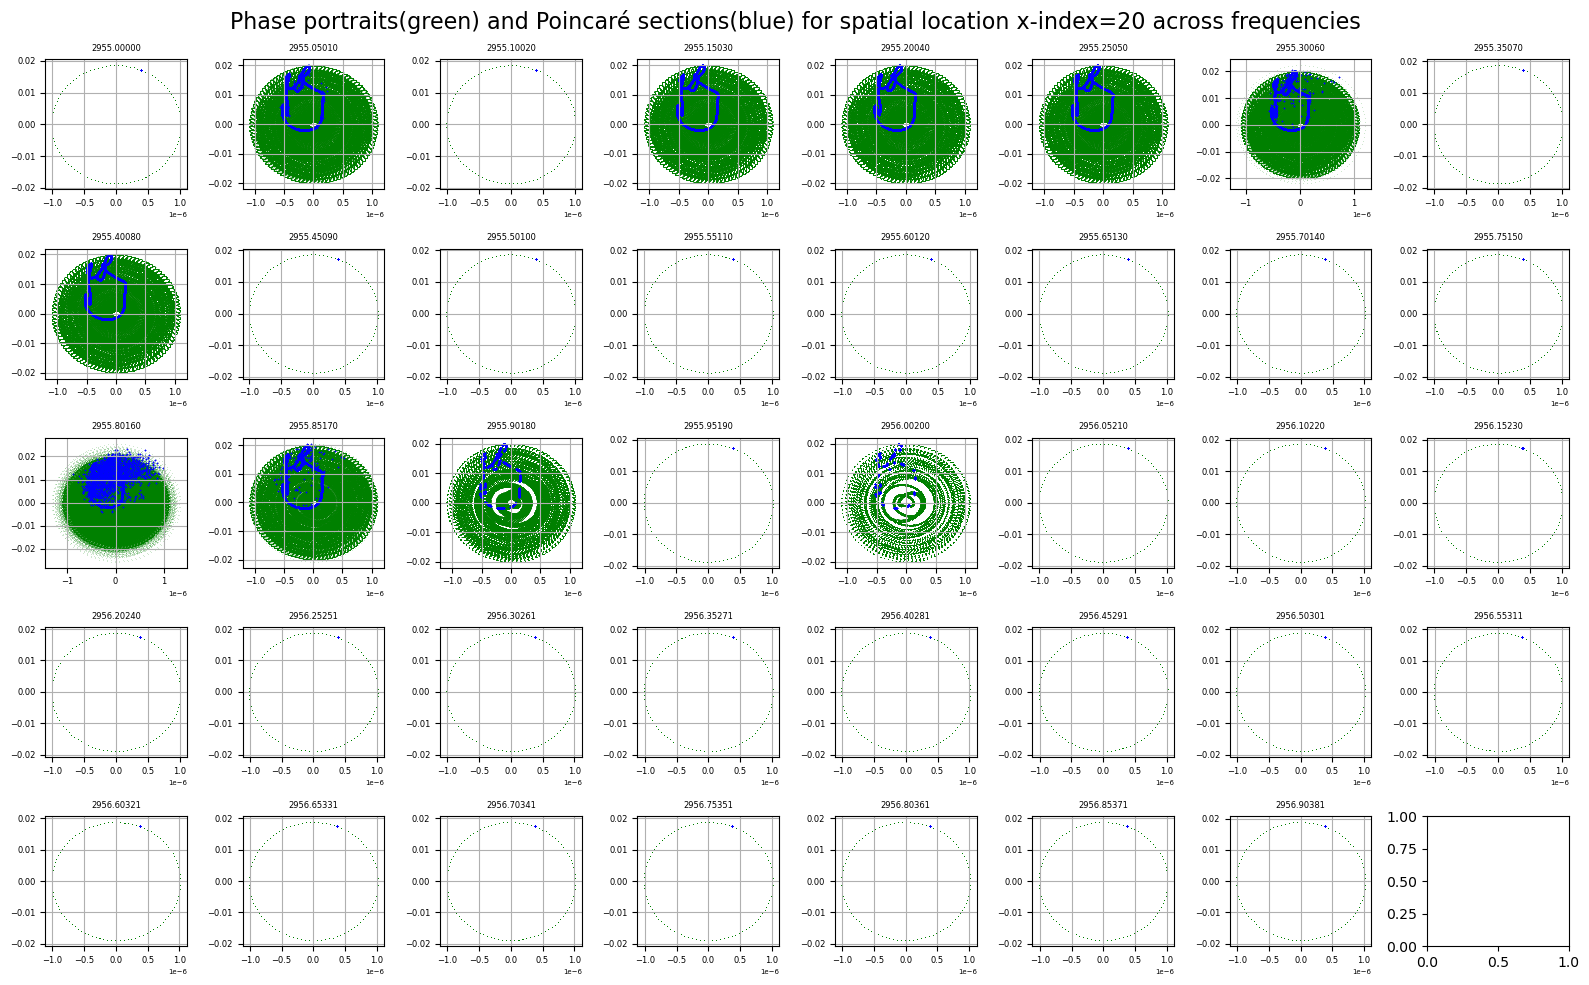

2977.94589

In [19]:
# 2D Phase portraits + Poincare section point velocity/displacement, multi-frequency
import scipy

sweep_indices = slice(0, 39, 1)
# freq_indices = slice(0, len(results_freq), max(1, len(results_freq)//25))
ncols = 8
nrows = 5
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 10) 
                        #  , sharex=True, sharey=True 
                         )
# r = results_freq[fidx]
n_periods_total = 10000
n_periods_keep = 5000
points_per_period = 100
x_indices = [20,]
# n_periods_keep = 2000
t_inds_keep = n_periods_keep * points_per_period
for i, r in enumerate(results[sweep_indices]):
    veloc = r["veloc"][x_indices, :].ravel()
    disp = scipy.integrate.cumulative_trapezoid(veloc, r["t"], initial=0, axis=-1)
    # z, v = r["eta"][x_indices, -t_inds_keep:], r["eta_dot"][x_indices, -t_inds_keep:]
    col, row = i % ncols, i // ncols
    veloc_poincare = stroboscopic_sample(r["t"], veloc, points_per_period, n_periods_keep)["response_poincare"]
    disp_poincare = stroboscopic_sample(r["t"], disp, points_per_period, n_periods_keep)["response_poincare"]
    # z_poincare, v_poincare = r["eta_poincare"][x_indices, -n_periods_keep:], r["eta_dot_poincare"][x_indices, -n_periods_keep:]
    axes[row, col].scatter(disp[-t_inds_keep:], veloc[-t_inds_keep:], s=0.02, color='green', lw=0.2, alpha=0.95, )
    axes[row, col].scatter( disp_poincare, veloc_poincare, s=0.5, color='blue', lw=1, alpha=0.95, marker='x')
    sweep_param = r._metadata.get("sweep_param")
    axes[row, col].set_title(f'{sweep_param:.5f}', fontsize=6)
    axes[row, col].grid(True)
    axes[row, col].tick_params(axis='both', which='major', labelsize=6)
    axes[row, col].xaxis.get_offset_text().set_fontsize(5)
# axes[i//5, i%5].legend(loc='best', fontsize=8, ncol=2)
fig.suptitle(f'Phase portraits(green) and Poincaré sections(blue) for spatial location x-index={x_indices[0]} across frequencies', fontsize=16)
fig.tight_layout()
plt.show()
2977.94589

In [ ]:
x_indices = [10, 20]
veloc = r["veloc"][x_indices, :]
veloc.shape

(2, 1000000)

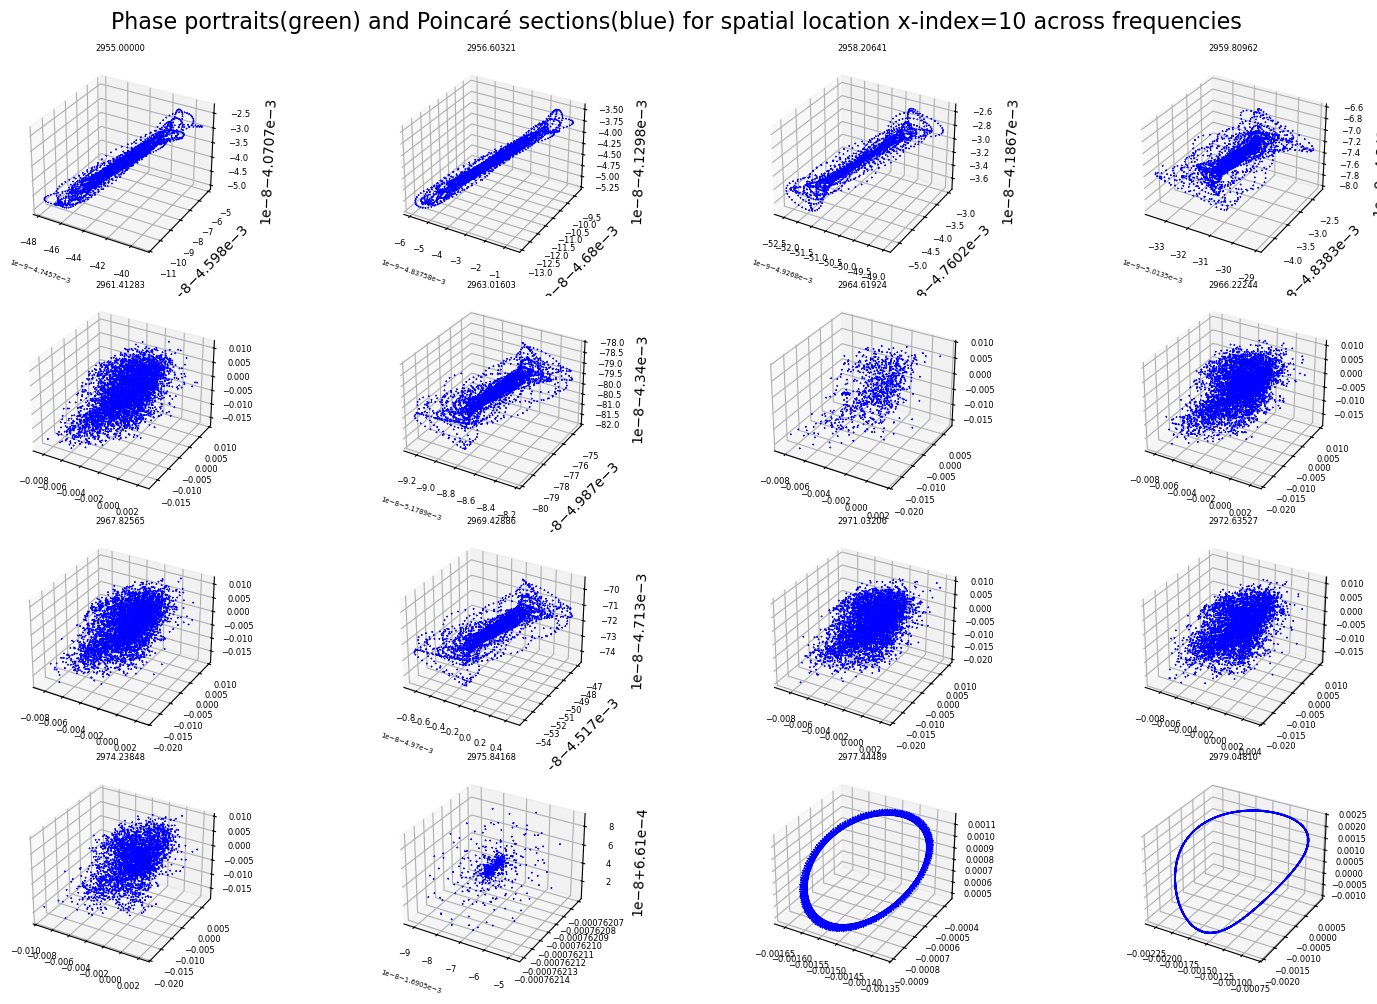

2977.94589

In [18]:
# 3D 3-point velocity strobe
import scipy

sweep_indices = slice(0, 500, 500//16 +1)
# freq_indices = slice(0, len(results_freq), max(1, len(results_freq)//25))
ncols = 4
nrows = 4
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 10), subplot_kw={'projection': '3d'}
                        #  , sharex=True, sharey=True 
                         )
# r = results_freq[fidx]
n_periods_total = 10000
n_periods_keep = 5000
points_per_period = 100
x_indices = [10,40, 70]
# n_periods_keep = 2000
t_inds_keep = n_periods_keep * points_per_period
for i, r in enumerate(results[sweep_indices]):
    veloc = r["veloc"][x_indices, :]
    # disp = scipy.integrate.cumulative_trapezoid(veloc, r["t"], initial=0, axis=-1)
    # z, v = r["eta"][x_indices, -t_inds_keep:], r["eta_dot"][x_indices, -t_inds_keep:]
    col, row = i % ncols, i // ncols
    veloc_poincare = stroboscopic_sample(r["t"], veloc, points_per_period, n_periods_keep)["response_poincare"]
    # veloc_poincare_p2 = stroboscopic_sample(r["t"], veloc[1, :], points_per_period, n_periods_keep)["response_poincare"]
    # z_poincare, v_poincare = r["eta_poincare"][x_indices, -n_periods_keep:], r["eta_dot_poincare"][x_indices, -n_periods_keep:]
    # axes[row, col].scatter(veloc[0,-t_inds_keep:], veloc[1,-t_inds_keep:], veloc[2,-t_inds_keep:], s=0.02, color='green', lw=0.2, alpha=0.95, )
    axes[row, col].scatter( veloc_poincare[0,:], veloc_poincare[1,:], veloc_poincare[2,:], s=0.5, color='blue', lw=1, alpha=0.95, marker='x')
    sweep_param = r._metadata.get("sweep_param")
    axes[row, col].set_title(f'{sweep_param:.5f}', fontsize=6)
    axes[row, col].grid(True)
    axes[row, col].tick_params(axis='both', which='major', labelsize=6)
    axes[row, col].xaxis.get_offset_text().set_fontsize(5)
# axes[i//5, i%5].legend(loc='best', fontsize=8, ncol=2)
fig.suptitle(f'Phase portraits(green) and Poincaré sections(blue) for spatial location x-index={x_indices[0]} across frequencies', fontsize=16)
fig.tight_layout()
plt.show()
2977.94589

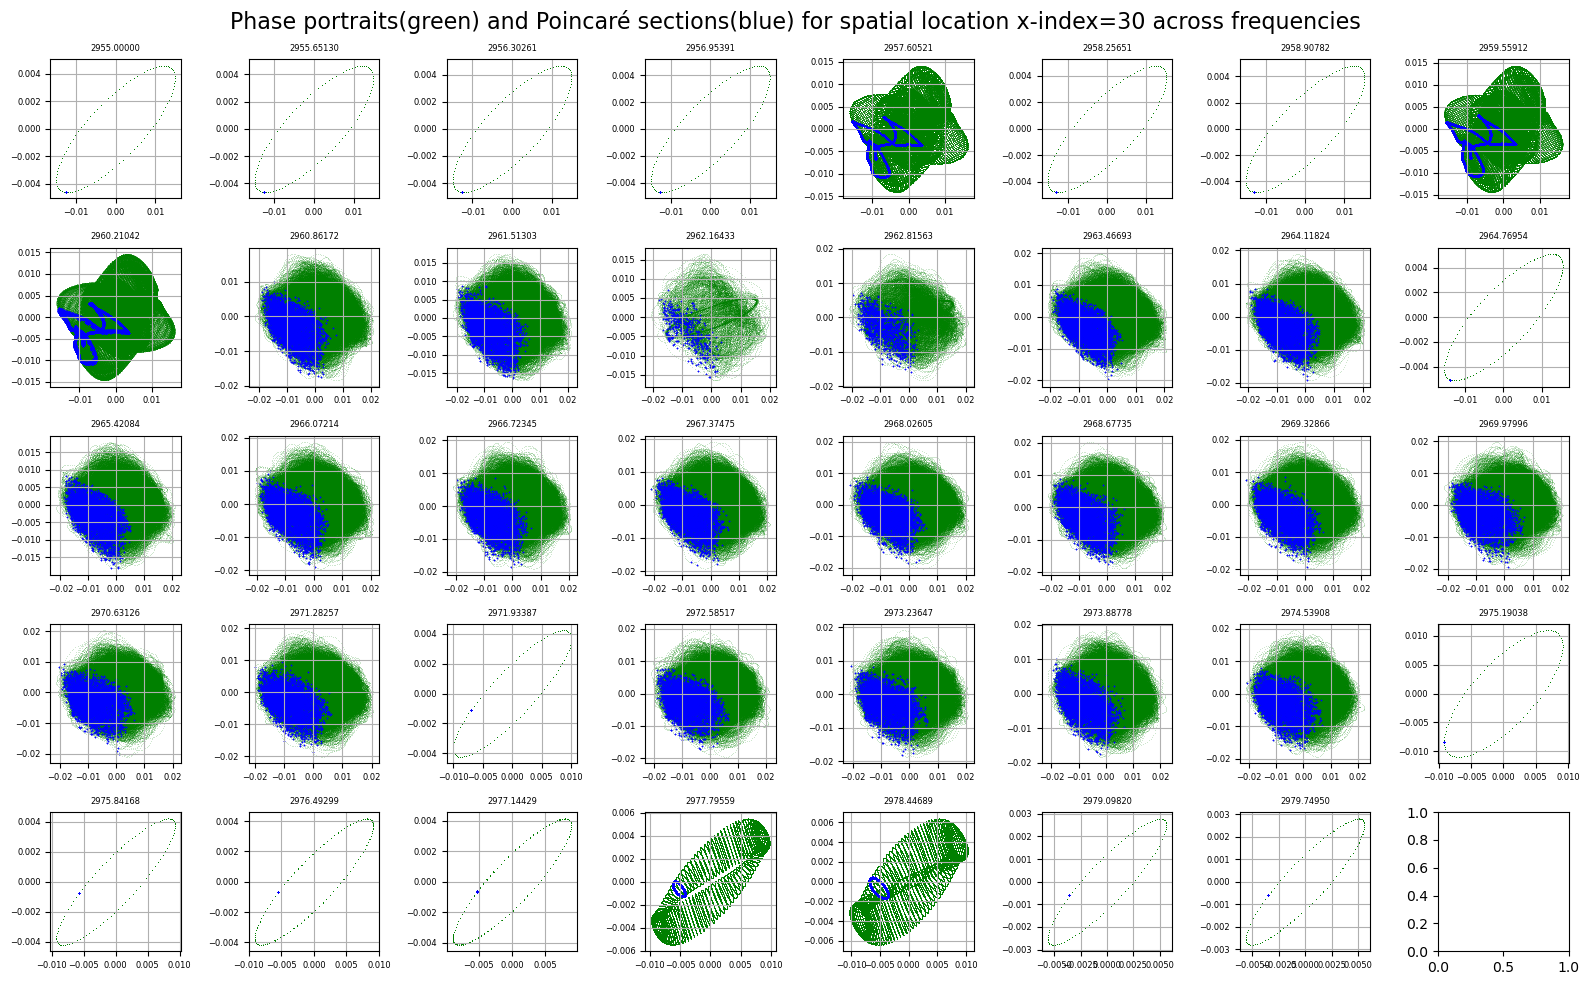

2977.94589

In [15]:
# 2D 2-point velocity strobe
import scipy

sweep_indices = slice(0, 500, 500//40+1)
# freq_indices = slice(0, len(results_freq), max(1, len(results_freq)//25))
ncols = 8
nrows = 5
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 10) 
                        #  , sharex=True, sharey=True 
                         )
# r = results_freq[fidx]
n_periods_total = 10000
n_periods_keep = 5000
points_per_period = 100
x_indices = [30, 40]
# n_periods_keep = 2000
t_inds_keep = n_periods_keep * points_per_period
for i, r in enumerate(results[sweep_indices]):
    veloc = r["veloc"][x_indices, :]
    # disp = scipy.integrate.cumulative_trapezoid(veloc, r["t"], initial=0, axis=-1)
    # z, v = r["eta"][x_indices, -t_inds_keep:], r["eta_dot"][x_indices, -t_inds_keep:]
    col, row = i % ncols, i // ncols
    veloc_poincare = stroboscopic_sample(r["t"], veloc, points_per_period, n_periods_keep)["response_poincare"]
    # veloc_poincare_p2 = stroboscopic_sample(r["t"], veloc[1, :], points_per_period, n_periods_keep)["response_poincare"]
    # z_poincare, v_poincare = r["eta_poincare"][x_indices, -n_periods_keep:], r["eta_dot_poincare"][x_indices, -n_periods_keep:]
    axes[row, col].scatter(veloc[0,-t_inds_keep:], veloc[1,-t_inds_keep:], s=0.02, color='green', lw=0.2, alpha=0.95, )
    axes[row, col].scatter( veloc_poincare[0,:], veloc_poincare[1,:], s=0.5, color='blue', lw=1, alpha=0.95, marker='x')
    sweep_param = r._metadata.get("sweep_param")
    axes[row, col].set_title(f'{sweep_param:.5f}', fontsize=6)
    axes[row, col].grid(True)
    axes[row, col].tick_params(axis='both', which='major', labelsize=6)
    axes[row, col].xaxis.get_offset_text().set_fontsize(5)
# axes[i//5, i%5].legend(loc='best', fontsize=8, ncol=2)
fig.suptitle(f'Phase portraits(green) and Poincaré sections(blue) for spatial location x-index={x_indices[0]} across frequencies', fontsize=16)
fig.tight_layout()
plt.show()
2977.94589

In [ ]:
# Animated grid of 2D phase portraits for selected piezos over frequencies
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from math import ceil
from pathlib import Path

def animate_piezos_grid(piezo_indices, freq_indices=None, freqs=None, results_list=None, ncols=4, figsize=(12,8), interval=500, save_path=None, fps=None):
    # pick results source
    results = results_list if results_list is not None else globals().get('results_freq', None)
    if results is None:
        results = globals().get('results_amp', None)
    if results is None:
        raise RuntimeError('No `results_freq` or `results_amp` found in workspace')

    # build freq->result mapping (results_freq items have key 'f')
    freq_map = {}
    avail = []
    for r in results:
        f = r.get('f', r._metadata.get('f')) or float(r.get('freq') if np.isscalar(r.get('freq', None)) else (r.get('f', np.nan)))
        if f is None:
            continue
        freq_map[float(f)] = r
        avail.append(float(f))
    avail = sorted(set(avail))

    # choose frames: default = all frequencies; otherwise use indices or explicit frequencies
    if freq_indices is not None:
        frames_freq = [avail[i] for i in freq_indices if 0 <= i < len(avail)]
    elif freqs is not None:
        frames_freq = []
        for fq in freqs:
            nearest = min(avail, key=lambda a: abs(a - fq))
            if nearest not in frames_freq:
                frames_freq.append(nearest)
    else:
        frames_freq = avail

    frames = [freq_map[f] for f in frames_freq]

    def _as_2d_series(arr, pidx):
        arr = np.asarray(arr)
        if arr.ndim == 2:
            return arr[pidx] if pidx < arr.shape[0] else arr.ravel()
        return arr.ravel()

    all_z = []
    all_v = []
    for r in frames:
        z_all = r.get('z_poincare', r.get('z'))
        v_all = r.get('v_poincare', r.get('v'))
        for pidx in piezo_indices:
            z = _as_2d_series(z_all, pidx)
            v = _as_2d_series(v_all, pidx)
            all_z.append(np.asarray(z).ravel())
            all_v.append(np.asarray(v).ravel())
    z_all = np.concatenate(all_z) if all_z else np.array([0.0, 1.0])
    v_all = np.concatenate(all_v) if all_v else np.array([0.0, 1.0])
    z_pad = 0.05 * (np.nanmax(z_all) - np.nanmin(z_all) + 1e-12)
    v_pad = 0.05 * (np.nanmax(v_all) - np.nanmin(v_all) + 1e-12)

    n = len(piezo_indices)
    nrows = ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.atleast_1d(axes).flatten()

    scatters = []
    for i, pidx in enumerate(piezo_indices):
        ax = axes[i]
        ax.set_xlabel('flux linkage (z)')
        ax.set_ylabel('voltage (v)')
        ax.set_title(f'Piezo {pidx}')
        ax.set_xlim(np.nanmin(z_all) - z_pad, np.nanmax(z_all) + z_pad)
        ax.set_ylim(np.nanmin(v_all) - v_pad, np.nanmax(v_all) + v_pad)
        ax.grid(True, alpha=0.25)
        sc = ax.scatter([], [], s=6)
        scatters.append(sc)
    # turn off unused axes
    for j in range(n, len(axes)):
        axes[j].axis('off')

    def update(frame_i):
        r = frames[frame_i]
        for sc_i, pidx in enumerate(piezo_indices):
            # prefer poincare arrays if present
            z_all = r.get('z_poincare', r.get('z'))
            v_all = r.get('v_poincare', r.get('v'))
            try:
                z = _as_2d_series(z_all, pidx)
                v = _as_2d_series(v_all, pidx)
            except Exception:
                z = np.asarray(z_all).ravel()
                v = np.asarray(v_all).ravel()
            pts = np.column_stack([z, v])
            scatters[sc_i].set_offsets(pts)
        fig.suptitle(f'Frequency = {frames_freq[frame_i]:.1f} Hz')
        return scatters

    anim = FuncAnimation(fig, update, frames=len(frames), interval=interval, blit=False, repeat=True)
    plt.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        fps = fps or max(1, int(round(1000 / interval)))
        if save_path.suffix.lower() == '.gif':
            anim.save(str(save_path), writer='pillow', fps=fps)
        else:
            try:
                anim.save(str(save_path), writer='ffmpeg', fps=fps)
            except Exception:
                fallback = save_path.with_suffix('.gif')
                anim.save(str(fallback), writer='pillow', fps=fps)
                save_path = fallback
        print(f'Saved animation to {save_path}')

    return anim

# Example usage (uncomment to run):
# anim = animate_piezos_grid([0,5,10,15], freq_indices=[0, 2, 4, 6], ncols=2, interval=400, save_path='piezos.gif')
anim = animate_piezos_grid([0,2, 4, 6, 8, 10, 12, 16, 20, 24, 28], save_path='piezos.gif')  # uses all available frequencies by default
from IPython.display import HTML
# HTML(anim.to_jshtml())

In [ ]:
# 3D Phase portraits at single frequency

fig = plt.figure(figsize=(8.5, 5.8))
ax = fig.add_subplot(111, projection='3d')
fidx = 10
r = results_freq[fidx]

indices = [0, 5, 10, 15, 20 , 25]
colors = plt.cm.viridis(np.linspace(0, 1, len(indices) ))
n_periods_keep = 5000
t_inds_keep = n_periods_keep * points_per_period
for i, (idx, z, v) in enumerate(zip(indices,r["z"][indices,-t_inds_keep:], r["v"][indices,-t_inds_keep:])):
    ax.plot(np.ones_like(z)*idx, r['t'][-t_inds_keep:], v, color=colors[i], lw=0.8, alpha=0.95)

ax.set_xlabel('Piezo index')
ax.set_xticks(indices)
ax.set_ylabel('time [s]')
ax.set_zlabel('v [V]')
ax.set_title(f'Phase portrait at {freqs[fidx]:.0f} Hz')
ax.grid(False )
ax.legend(loc='best', fontsize=8, ncol=2)
fig.tight_layout()
plt.show()

In [ ]:
# 3D Poincaré section at single frequency
fig = plt.figure(figsize=(8.5, 5.8))
ax = fig.add_subplot(111, projection='3d')
r = results_freq[fidx]

indices = [20]
freq_slice = slice(0, None, 5)
colors = plt.cm.viridis(np.linspace(0, 1, len(results_freq[freq_slice]) ))
n_periods_keep = 1000
t_inds_keep = n_periods_keep * points_per_period
for j, r in enumerate(results_freq[freq_slice]):
    for i, (idx, z, v) in enumerate(zip(indices,r["z_poincare"][indices,-t_inds_keep:], r["v_poincare"][indices,-t_inds_keep:])):
        ax.scatter(np.ones_like(z)*r['f'], z, v, color=colors[j], s=10, lw=0.5, alpha=0.95)

ax.set_xlabel('frequency [Hz]')
ax.set_xticks([r['f'] for j, r in enumerate(results_freq[freq_slice])])
ax.set_zlabel('voltage [V]')
ax.set_ylabel('flux linkage [V.s]')
ax.set_title(f'Poincaré section of piezo no. {indices[0]:.0f} ')
ax.grid(False )
ax.legend(loc='best', fontsize=8, ncol=2)
fig.tight_layout()
plt.show()

In [ ]:
# 2D bifurcation diagram of velocity (Poincaré section voltage vs frequency)
fig = plt.figure(figsize=(8.5, 5.8))
ax = fig.add_subplot(111,)
r = results_freq[fidx]

indices = [15]
colors = plt.cm.viridis(np.linspace(0, 1, len(results_freq) ))
n_periods_keep = 5000
# t_inds_keep = n_periods_keep * points_per_period
points_per_period = 100
for j, r in enumerate(results_freq):
    veloc = r['veloc'][indices, :]
    strobe = stroboscopic_sample(r['t'], veloc, points_per_period, n_periods_keep)
    info = strobe['response_poincare']
    ax.scatter(r['f']*np.ones_like(info), info, 
               color='b',#colors[j], 
               s=0.02, alpha=1)
ax.set_xlabel('frequency [Hz]')
# ax.set_xticks([j for j, r in enumerate(results_freq)])
# ax.set_zlabel('v [V]')
ax.set_title(f'poincaré section voltage {indices[0]:.0f} Hz')
ax.grid(False )
ax.legend(loc='best', fontsize=8, ncol=2)
fig.tight_layout()
plt.show()

In [ ]:
# 2D bifurcation diagram of single piezo voltage/flux linkage (Poincaré section voltage vs frequency)
fig = plt.figure(figsize=(8.5, 5.8))
ax = fig.add_subplot(111,)
r = results_freq[fidx]

indices = [15]
colors = plt.cm.viridis(np.linspace(0, 1, len(results_freq) ))
n_periods_keep = 5000
# t_inds_keep = n_periods_keep * points_per_period
for j, r in enumerate(results_freq):
    # veloc = r['veloc']
    # strobe = stroboscopic_sample(r['t'], veloc, points_per_period, n_periods_keep)
    # info = strobe['response_poincare'][indices, :]
    info = r['v_poincare'][indices, :]
    ax.scatter(r['f']*np.ones_like(info), info, 
               color='b',#colors[j], 
               s=0.02, alpha=1)
ax.set_xlabel('frequency [Hz]')
# ax.set_xticks([j for j, r in enumerate(results_freq)])
# ax.set_zlabel('v [V]')
ax.set_title(f'poincaré section voltage {indices[0]:.0f} Hz')
ax.grid(False )
ax.legend(loc='best', fontsize=8, ncol=2)
fig.tight_layout()
plt.show()